In [1]:
import sys
sys.path.append("../")

from config import *
from figs_config import *

Loaded aesthetics module


# Empirical surface maps

## _Data specs_

In [2]:
import joblib
src_pvdata = joblib.load( projdir + '/data/fsLR-4k_reduced-midthickness_neuromaps.pkl')

In [3]:
import pandas as pd
maptags = pd.read_table(projdir + '/data/surf_map_names', delimiter = " ", dtype = str)
maptags = list(maptags.columns)

In [4]:
space = 'fsLR-4k'
geometry = 'reduced-midthickness'
datasource = 'neuromaps'
strategy = 'dsk33'
niters = 100

## Explain sampling

In [28]:
# load dsk centroids
import joblib
sphere_dsk33 = joblib.load( projdir + '/data/fsLR-4k_sphere_parc-dsk33.pkl')
ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')


In [29]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# number of discrete levels
N = 34

# get continuous colormap
cmap = plt.cm.cubehelix

# sample 34 colors evenly
colors = cmap(np.linspace(0.15, .9, N))
# shuffle the colors
np.random.seed(321)
dsk_colours = colors[np.random.choice(N, N)]

# create discrete colormap
discrete_cmap = mcolors.ListedColormap(np.vstack([np.ones(4),dsk_colours]), name="wcuhe34")

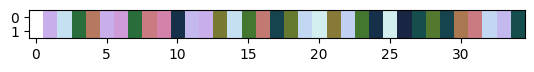

In [30]:
import matplotlib.pyplot as plt
import numpy as np

data = np.vstack([ np.arange(35), np.arange(35) ] )

plt.imshow(
    data, 
    cmap=discrete_cmap
)
plt.show()

In [31]:
examples = ['rostralmiddlefrontal', 'superiorparietal', 'entorhinal', 'pericalcarine']


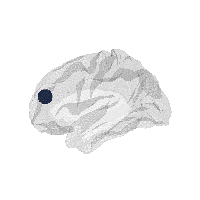

In [32]:
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

pl.add_mesh(src_pvdata.rotate_z(180), opacity = 0.1, color = 'white', show_edges=True, **mesh_aes)
pl.add_points(pv.PolyData(ctx_dsk33[2][ctx_dsk33[0].index(examples[0])]).rotate_z(180), \
              color = dsk_colours[ctx_dsk33[0].index(examples[0])-1], point_size = 15, **point_aes)

pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

In [33]:
reduced_mesh = joblib.load('/home/yzhou/projects/interpolate/data/fsLR-4k_reduced-midthickness_neuromaps_parc.pkl')
reduced_sphere = joblib.load('/home/yzhou/projects/interpolate/data/fsLR-4k_reduced-sphere.pkl')
sphere = joblib.load(projdir + '/data/fsLR-4k_sphere_grf.pkl')

In [34]:
dsk_centroids_sphere = joblib.load('/home/yzhou/projects/interpolate/data/fsLR-4k_sphere_parc-dsk33.pkl')[2]


In [35]:
import numpy as np

def gaussian_sphere(mesh_vertices, center, sigma):

    # compute gaussian weights over the spherical mesh centered around a focal vertex
    
    center = center / np.linalg.norm(center)
    mesh_vertices = mesh_vertices / np.linalg.norm(mesh_vertices, axis=1, keepdims=True) # normalize
    dot_products = np.clip(np.dot(mesh_vertices, center), -1.0, 1.0)
    angles = np.arccos(dot_products)  # Angular distances in radians

    values = np.exp(-(angles**2) / (2 * sigma**2))
    return values

In [36]:
from interpmodules import helpers
from scipy.spatial import KDTree


focus = dsk_centroids_sphere[ctx_dsk33[0].index(examples[0])]

parcellated = reduced_mesh['dsk33']

parcel_verts = np.where(parcellated == 26)[0]
whole_brain_weights = gaussian_sphere(reduced_sphere.points, focus, .5)

in_parcel_weights = whole_brain_weights[parcel_verts]

in_parcel_probabilities = in_parcel_weights / in_parcel_weights.sum()

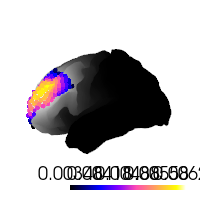

In [37]:
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

pl.add_mesh(reduced_mesh.rotate_z(180), scalars = whole_brain_weights, cmap = 'gist_yarg_r',  **mesh_aes)
#pl.add_points(pv.PolyData(focus).rotate_z(180), point_size = 12, **point_aes)
pl.add_points(pv.PolyData(reduced_mesh.points[parcel_verts]).rotate_z(180), cmap = 'gnuplot2', \
              scalars = in_parcel_probabilities, **point_aes)
pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

In [38]:
sampling = joblib.load(projdir + '/data/sampling/fsLR-4k_reduced-midthickness_samp-dsk33_pct-10_iters-100.pkl')

In [39]:
kc=sampling[1][0][:,:,40]
kv=sampling[1][1][:,40]
subset = np.intersect1d(kv, parcel_verts)

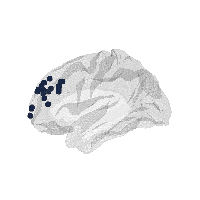

In [40]:
import pyvista as pv

pl = pv.Plotter(window_size = (200,200))

pl.add_mesh(src_pvdata.rotate_z(180), opacity = 0.1, color = 'white', show_edges=True, **mesh_aes)
#pl.add_points(pv.PolyData(focus).rotate_z(180), point_size = 12, **point_aes)
pl.add_points(pv.PolyData(reduced_mesh.points[subset.astype(int)]).rotate_z(180), \
              point_size = 6, color = dsk_colours[ctx_dsk33[0].index(examples[0])-1], \
              **point_aes)
pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

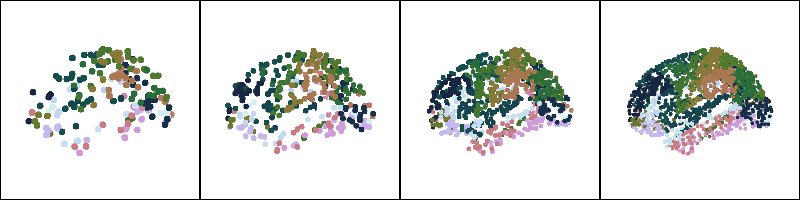

In [41]:
pl = pv.Plotter(shape = (1,4), window_size = (800,200))

ps = [7,6,5,4]
for pi, p in enumerate(test_percentages):

    sampling = joblib.load(projdir + f'/data/sampling/fsLR-4k_reduced-midthickness_samp-dsk33_pct-{p}_iters-100.pkl')

    kc=sampling[1][0][:,:,40]
    kv=sampling[1][1][:,40]

    cvals = parcellated[kv.astype(int)]
    
    pl.subplot(0,pi)

    #pl.add_mesh(src_pvdata.rotate_z(180), color = 'lightgray', **mesh_aes)
    pl.add_points(pv.PolyData(kc).rotate_z(180), scalars = cvals, point_size = ps[pi], cmap = discrete_cmap, \
                  show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

## Voronoi Standard Error

In [51]:
# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('YlOrBr')
pct_colours = lincmap(np.linspace(0.3, .6, len(test_percentages)))
sns.color_palette(pct_colours)

[(0.996078431372549, 0.8434755863129565, 0.4691580161476355),
 (0.996078431372549, 0.7349019607843138, 0.28),
 (0.9949711649365629, 0.5974778931180315, 0.15949250288350636),
 (0.939607843137255, 0.4713725490196078, 0.09490196078431372)]

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import zscore

all_standardized_voronoi_se = []

voronoi_se = np.zeros((niters, len(test_percentages)))
voronoi_se_zscored = np.zeros((niters, len(test_percentages)))

for pi, p in enumerate(test_percentages):
    labels, results = joblib.load(projdir + \
        f'/results/{datasource}/{strategy}/{space}_{maptags[0]}_{geometry}_{datasource}_samp-{strategy}_pct-{str(p)}.pkl')
    
    for i in range(niters):
        voronoi_se[i, pi] = results[0][i][2]

    voronoi_se_zscored[:,pi] = zscore( voronoi_se[:,pi] )

all_standardized_voronoi_se.append(voronoi_se_zscored)

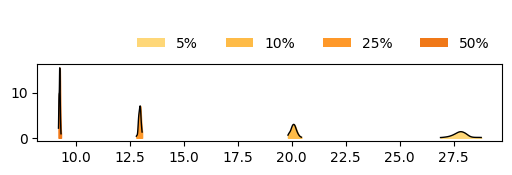

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import zscore, gaussian_kde

plt.figure(figsize = (6,1))
bins = np.histogram_bin_edges(voronoi_se.T, bins=25)

for pi, p in enumerate(test_percentages):

    data = voronoi_se[:,pi]
    #plt.hist(data, bins = bins, color = pct_colours[pi], edgecolor = 'w', density=True, alpha = 1)
    #plt.axvline(np.mean(voronoi_se[:,pi]), linewidth = 1, color = 'k', alpha = .5)
    x = np.linspace(data.min(), data.max(), 50)
    kde = gaussian_kde(data)
    plt.plot(x, kde(x), color = 'k', linewidth=1)

    x = np.linspace(data.min(), data.max(), 50)
    y = gaussian_kde(data)(x)
    
    plt.fill_between(x, y, 0, color = pct_colours[pi], alpha=1)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=pct_colours[pi], label=str(p) + "%")
    for pi, p in enumerate(test_percentages)
]

plt.legend(handles=legend_elements, title=" ", loc='lower right',
bbox_to_anchor=(1, 1.02), frameon=False, ncol = len(test_percentages))
plt.show()

In [22]:
for pi in range(len(test_percentages)):
    print("Sparse sample at: " + str(test_percentages[pi]) + "%")
    print('             mean VSE: ' + str(voronoi_se[:,pi].mean()) )
    print('             variance VSE: ' + str(voronoi_se[:,pi].std()) )

Sparse sample at: 5%
             mean VSE: 27.801388584418696
             variance VSE: 0.3175455716724613
Sparse sample at: 10%
             mean VSE: 20.093168342281658
             variance VSE: 0.12780017136936897
Sparse sample at: 25%
             mean VSE: 12.970009534698617
             variance VSE: 0.05287271941957281
Sparse sample at: 50%
             mean VSE: 9.259219011493085
             variance VSE: 0.02470086034221325


### Sample maps experimental variograms

we only concern ourselves with the fitting of the variogram because there is no "theoretical" model to compare with,
every MAE is calculated between the experimental variogram and an exponential model.

In [43]:
variogram_gof = []
variogram_percentages = []
variogram_maptags = []

In [45]:
from interpmodules import helpers, metrics
import skgstat as skg
from scipy.stats import zscore

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):    
        tags, results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')

        for i in range(niters):
            x, y, N, eff_range, psill, nugg = results[1][i]
    
            fit = [ helpers.exponential(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]
        
            joined = np.concat([fit, y])
            #rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
            #rescaled_fit = rescaled[:len(x)]
            #rescaled_emp = rescaled[len(x):]
            #variogram_gof.append( np.mean(metrics.metric(rescaled_fit, rescaled_emp, 'residual')) )

            # sill normalize
            variogram_gof.append( np.mean(metrics.metric(fit, y, 'residual')) / (psill + nugg) )
            
            variogram_percentages.append( percentage )
            variogram_maptags.append( maptag )

In [46]:
import pandas as pd
variogram_gof_plotdata = pd.DataFrame()
variogram_gof_plotdata['mae'] = variogram_gof
variogram_gof_plotdata['percentage'] = variogram_percentages
variogram_gof_plotdata['maptag'] = variogram_maptags

In [48]:
maptocat = {'gene expression': ['abagen_genepc1'], \
            'MEG': ['hcps1200_meg' + fband for fband in fbands ] + ['hcps1200_megtimescale'], \
            'structural': ['hcps1200_thickness', 'hcps1200_myelinmap'], \
            'functional': ['margulies2016_fcgradient01', 'mueller2013_intersubjvar', 'xu2020_FChomology', 'sydnor2021_SAaxis'], \
            'metabolism': ['raichle_cbf', 'raichle_cbv', 'raichle_cmr02', 'raichle_cmrglc'], \
            'expansion': ['hill2010_devexp', 'hill2010_evoexp', 'xu2020_evoexp', 'reardon2018_scalinghcp', 'reardon2018_scalingnih', 'reardon2018_scalingpnc']}

In [49]:
cat = []
for row in range(len(variogram_gof_plotdata)):
    for category in maptocat:
        if variogram_gof_plotdata.at[row, 'maptag'] in maptocat[category]:
            cat.append( category )
        else: continue

variogram_gof_plotdata['category'] = cat

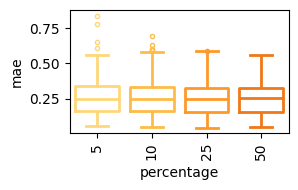

In [53]:
import seaborn as sns

plt.figure(figsize = (3,2))
sns.boxplot(variogram_gof_plotdata, x='percentage', y='mae', hue='percentage', \
            fliersize = 3, linewidth=2, palette = pct_colours, fill = False, linecolor = 'k', legend=False)
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

In [55]:
global_i_s = joblib.load(projdir + '/results/stats/neuromaps_fullmap_globalstats.pkl')

In [57]:
morder = list(global_i_s.index)

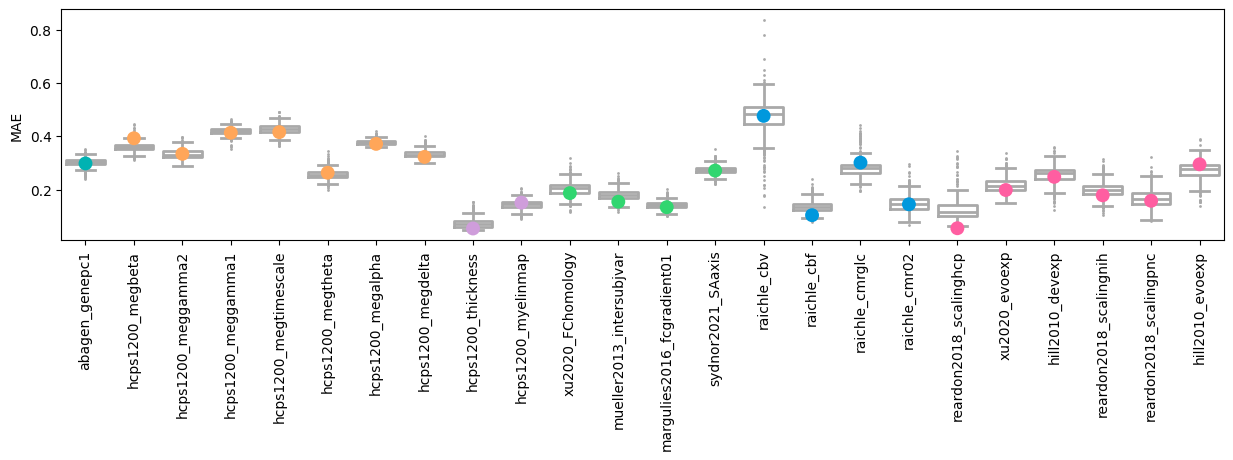

In [59]:
import seaborn as sns

plt.figure(figsize = (15,3))

sns.scatterplot(global_i_s, x=morder, y='mae-sillnorm', \
                hue = 'category', hue_order = corder, \
                palette = cpal, edgecolor = 'none',  s = 100, legend = False, zorder = 10
)

sns.boxplot( variogram_gof_plotdata, x='maptag', y='mae', order=morder, color='darkgray', fliersize=1, linewidth = 2, fill=False)


plt.xticks(rotation=90)
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("MAE")
plt.show()

## Sample maps variograms PCs

* import the results from the interpolation runs

In [61]:
from interpmodules import helpers, metrics
import skgstat as skg

variogram_percentages = []
variogram_maptags = []
variograms = []

Dist = helpers.internal_distance_matrix(src_pvdata.points, 'euclidean')

for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):
    
        tags, results = joblib.load( projdir + f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')

        for i in range(niters):
            x, y, N, eff_range, psill, nugg = results[tags.index('variogram')][i]
            h = x
            variograms.append(y)
            variogram_maptags.append(maptag)
            variogram_percentages.append(percentage)
            

In [62]:
import numpy as np

expvgm = np.vstack(variograms)

In [63]:
from skfda.representation.grid import FDataGrid
from scipy.stats import zscore

all_ev_z = zscore(expvgm.T, axis = 0)
datag = FDataGrid(all_ev_z)

In [64]:
import skfda

fpca = skfda.preprocessing.dim_reduction.FPCA(n_components=5)

In [65]:
fpca.fit(datag)

FPCA(_weights=array([3.47258395e-05, 1.38903358e-04, 6.94516790e-05, ...,
       1.30221898e-04, 1.04177518e-04, 4.34072994e-05], shape=(9600,)),
     n_components=5)

In [66]:
colour_categories = []

for vi, v in enumerate(variogram_maptags):
    colour_categories.append( cpal[ global_i_s.at[v, "category"] ] )

In [67]:
pct_colours_points = []

for pi, p in enumerate(variogram_percentages):
    pct_colours_points.append( pct_colours[ test_percentages.index(p) ] )

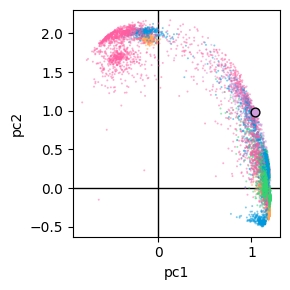

In [69]:
import matplotlib.pyplot as plt
plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

plt.scatter(xs, ys, s=2, c=colour_categories, edgecolor = 'none', alpha = .5, zorder=5, rasterized=True)
plt.scatter(xs[3741], ys[3741], s=40, c=colour_categories[3741], edgecolor = 'k', zorder=10)


plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()


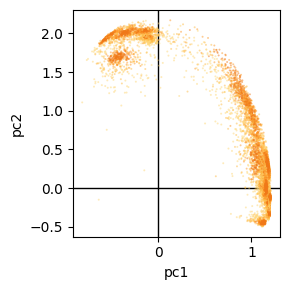

In [70]:
import matplotlib.pyplot as plt


plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

plt.axhline(0, color ='k', linewidth =1)
plt.axvline(0, color = 'k', linewidth=1)

plt.scatter(xs, ys, s=2, c=pct_colours_points, edgecolor = 'none', alpha = .5, zorder=10)

plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()

In [71]:
fpca.explained_variance_

array([0.71373983, 0.20758774, 0.0528024 , 0.0367961 , 0.01356511])

In [72]:
pcs = fpca.fit_transform(datag)

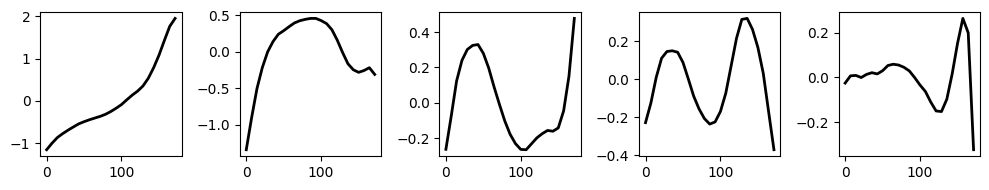

In [74]:
fig, axs = plt.subplots(1,5, figsize = (10, 2))

for c in range(fpca.n_components):
    axs[c].plot(h, pcs[:,c], color = 'k', linewidth=2)

plt.tight_layout()

In [75]:
pc_scores = pd.DataFrame({"maptag": variogram_maptags, \
                          "percentage": variogram_percentages, \
                           "pc1_scores": np.array(fpca.components_[0].data_matrix).flatten(), \
                           "pc2_scores": np.array(fpca.components_[1].data_matrix).flatten()})

In [76]:
df1 = pc_scores
df2 = variogram_gof_plotdata
common_cols = df1.columns.intersection(df2.columns)

In [77]:
samp_stats = pd.concat([variogram_gof_plotdata, pc_scores[["pc1_scores", "pc2_scores"]]], axis = 1)

In [78]:
samp_stats = samp_stats[['maptag', 'category', 'percentage', 'mae', 'pc1_scores', 'pc2_scores']]

In [79]:
samp_stats["mae-sillnorm"] = samp_stats["mae"]

In [80]:
samp_stats = samp_stats.drop(columns = ["mae"])

In [82]:
sample_global_i_s = np.load(projdir + '/results/stats/neuromaps_samples_global_i_s.npy')
samples_i_s = pd.DataFrame(sample_global_i_s.mean(axis=0).T, columns=[maptags], index=np.arange(100))

In [83]:
samp_stats['sample_i'] = sample_global_i_s.flatten()

In [95]:
print(samp_stats.loc[ np.where( samp_stats['mae-sillnorm'] == samp_stats['mae-sillnorm'].min() ) ])

                  maptag    category  percentage  pc1_scores  pc2_scores  \
3830  hcps1200_thickness  structural          25    1.063946    0.930151   

      mae-sillnorm  sample_i  
3830       0.04817  0.082692  


In [85]:
colour_thickness = []

corder = ['gene expression', 'MEG', 'structural', 'functional', 'metabolism', 'expansion']
ccolours = [
    (1,1,1,0),  # gene: light turquoise
    (1,1,1,0),  # MEG: orange
    to_hex(plt.cm.cubehelix(0.7)),  # structural: violet
    (1,1,1,0),  # functional: green
    (1,1,1,0), # metabolism: blue
    (1,1,1,0) # expansion: pink
]

thickness_cpal = dict(zip(corder, ccolours))
sns.color_palette(ccolours)

for vi, v in enumerate(variogram_maptags):
    colour_thickness.append( thickness_cpal[ global_i_s.at[v, "category"] ] )

In [86]:
metadata = joblib.load(projdir + '/results/stats/neuromaps_collected_expvgm_fit_sill-normalized.pkl')

In [103]:
df = np.hstack( [metadata.loc[thickness_ind.astype(int)], expvgm[thickness_ind.astype(int),:]])
df = pd.DataFrame(df, columns = ['mae', 'percentage', 'maptag'] + list(range(25)))

In [104]:

import pandas as pd

# assuming your dataframe is called df

# columns that should stay fixed
id_vars = ["mae", "percentage", "maptag"]

# melt the bin columns (0–24) into rows
df_long = df.melt(
    id_vars=id_vars,
    var_name="bin",
    value_name="semivariance"
)

# optional: ensure bin is numeric (since column names become strings)
df_long["bin"] = df_long["bin"].astype(int)

print(df_long.head())

        mae percentage              maptag  bin semivariance
0  0.077311          5  hcps1200_thickness    0     0.004229
1  0.076218          5  hcps1200_thickness    0     0.009756
2  0.096229          5  hcps1200_thickness    0     0.007552
3  0.132834          5  hcps1200_thickness    0      0.00858
4  0.133104          5  hcps1200_thickness    0     0.009969


In [87]:
thickness_ind = np.where( metadata['maptag'] == 'hcps1200_thickness')[0]

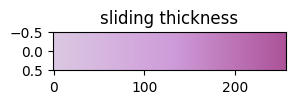

In [97]:
pur,_ = three_colours_gradient(lo=plt.cm.PuRd(0.2), mid=plt.cm.cubehelix(0.7), hi=plt.cm.vanimo(0.2), plot=False)
show_colour_scheme(pur, "sliding thickness")

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# Get an existing colormap and sample a segment
lincmap = pur
pct_colours = lincmap(np.linspace(0,1, len(test_percentages)))
sns.color_palette(pct_colours)

[(0.8611764705882353, 0.788235294117647, 0.8878431372549019),
 (0.82854469724954, 0.673447989731375, 0.8677740659312789),
 (0.7680228723305961, 0.5201826168735704, 0.7737062567603665),
 (0.67817, 0.32479, 0.6034)]

In [105]:
pct_colours_long = []
for i in range(len(df)):
    j = test_percentages.index( df.at[i,'percentage'] )
    pct_colours_long.append( pct_colours[j] )

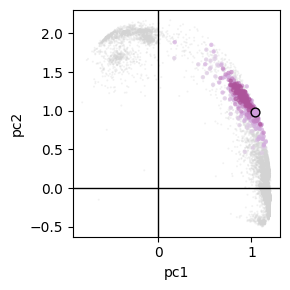

In [106]:
import matplotlib.pyplot as plt
plt.subplots(figsize = (3,3))

xs = np.array(fpca.components_[0].data_matrix).flatten()
ys = np.array(fpca.components_[1].data_matrix).flatten()

xs_thickness = np.array(fpca.components_[0].data_matrix).flatten()[thickness_ind.astype(int)]
ys_thickness = np.array(fpca.components_[1].data_matrix).flatten()[thickness_ind.astype(int)]

plt.axhline(0, color ='k', linewidth =1, zorder=10)
plt.axvline(0, color = 'k', linewidth=1, zorder=10)

plt.scatter(xs, ys, s=2, c='lightgray', edgecolor = 'none', alpha = 0.3, rasterized=True)
plt.scatter(xs_thickness, ys_thickness, s=10, c=pct_colours_long, alpha = 0.7, edgecolor = 'none', zorder=10, rasterized=True)

plt.scatter(xs[3741], ys[3741], s=40, c=colour_categories[3741], edgecolor = 'k', zorder=10)


plt.xlabel('pc1')
plt.ylabel('pc2')
plt.tight_layout()
plt.show()

In [111]:
difference_from_min_mae = samp_stats['mae-sillnorm']
min_mae_ridx = samp_stats.loc[ difference_from_min_mae.argsort()[0] ].name

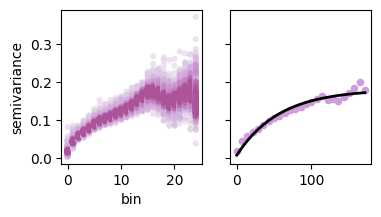

In [112]:
from interpmodules import helpers
from scipy.optimize import curve_fit

model = helpers.exponential
u=h
ev=expvgm[min_mae_ridx]
nparams = 3
nh=25
bounds = ([0.00001]*nparams, [np.nanmax(u), np.nanmax(ev), np.nanmax(ev)/nh])

cof, cov = curve_fit(model, u, ev, method = 'trf', p0=bounds[1], bounds = bounds, maxfev=1000)
v_pred = model(h, *cof)


fig, axs = plt.subplots(1,2, figsize = (4,2), sharey=True)

sns.scatterplot(df_long, x='bin', y='semivariance', edgecolor = 'none', \
                hue = 'percentage', s=20, alpha = 0.5, palette = pct_colours, legend=False, rasterized=True, ax=axs[0])

axs[1].plot(h, v_pred, c="k", linewidth = 2, alpha = 1)
axs[1].scatter(h, expvgm[min_mae_ridx], s=20, c=cpal['structural'], rasterized=True)
plt.show()

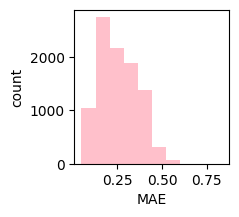

In [114]:
plt.figure(figsize = (2,2))
plt.hist( samp_stats['mae-sillnorm'], facecolor = 'pink')
plt.ylabel('count')
plt.xlabel('MAE')
plt.show()

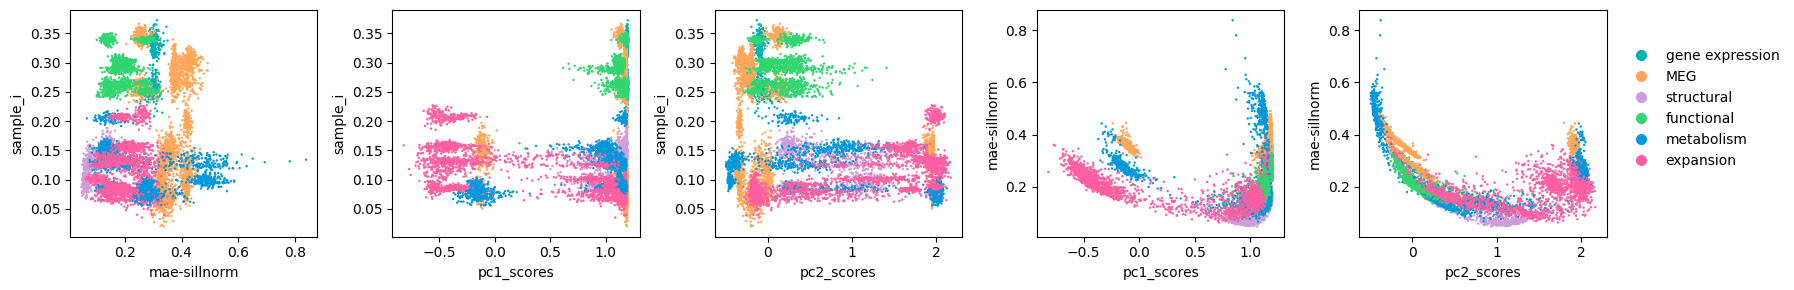

In [211]:
# add regression lines here

fig, axs = plt.subplots(1,5, figsize = (18,3))

for i, measure in enumerate(['mae-sillnorm', 'pc1_scores', 'pc2_scores']):
    
    sns.scatterplot( samp_stats, x=measure, y='sample_i', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[i], rasterized=True)
    
sns.scatterplot( samp_stats, x='pc1_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[3], rasterized=True)

sns.scatterplot( samp_stats, x='pc2_scores', y='mae-sillnorm', \
                    hue = 'category', palette=cpal, \
                     s=3, edgecolor = 'none',\
                     legend=False, ax=axs[4], rasterized=True)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="k", linewidth =0, \
           markeredgecolor = 'none',\
           markerfacecolor=to_rgba(ccolours[ci]), markersize=8, \
           label=cat)
    for ci, cat in enumerate(corder)
]

plt.legend(handles=legend_elements, \
           loc='lower right', \
           frameon=False, \
           ncol = 1,\
            bbox_to_anchor=(1.75, 0.25),  # outside right
            borderaxespad=0.5)


plt.tight_layout()
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_pc1-mae.svg')

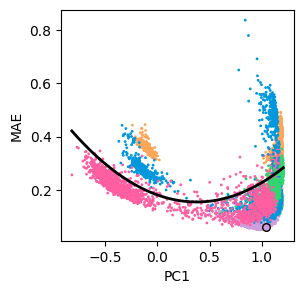

In [100]:
plt.figure(figsize = (3,3))

removed_nan = samp_stats.dropna()
df = removed_nan
x = df["pc1_scores"].to_numpy().astype(float)
y = df["mae-sillnorm"].to_numpy().astype(float)

coeffs = np.polyfit(x, y, 2)

# Create smooth curve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

plt.scatter(x=samp_stats['pc1_scores'], y=samp_stats['mae-sillnorm'], c=colour_categories, s= 1, rasterized = True,)
plt.scatter(x=samp_stats['pc1_scores'][min_mae_ridx], y=samp_stats['mae-sillnorm'][min_mae_ridx], \
            c=colour_categories[min_mae_ridx], edgecolor = 'k', s= 30, zorder=10)

plt.plot(x_fit, y_fit, color = 'k', linewidth = 2, zorder = 10)
plt.xlabel("PC1")
plt.ylabel("MAE")
plt.savefig(projdir + '/figs/main/neuromaps_variograms_dsk33_samples_pc1-mae_sill-normalized.svg')

In [218]:
coeffs

array([ 0.18701453, -0.14090649,  0.18095635])

In [219]:
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - ss_res / ss_tot
print("R²:", r2)

n = len(x)
p = 2  # number of predictors (not counting intercept)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adj_r2)


rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)


R²: 0.0932687448288424
Adjusted R²: 0.09307962578511075
RMSE: 0.10395844936504191


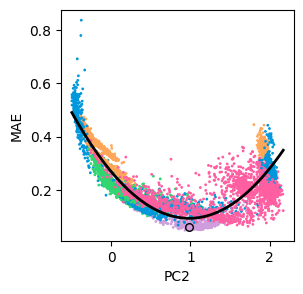

In [101]:
plt.figure(figsize = (3,3))

removed_nan = samp_stats.dropna()
df = removed_nan
x = df["pc2_scores"].to_numpy().astype(float)
y = df["mae-sillnorm"].to_numpy().astype(float)

coeffs = np.polyfit(x, y, 2)

# Create smooth curve
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = np.polyval(coeffs, x_fit)

plt.scatter(x=samp_stats['pc2_scores'], y=samp_stats['mae-sillnorm'], c=colour_categories, s= 1, rasterized = True,)
plt.scatter(x=samp_stats['pc2_scores'][min_mae_ridx], y=samp_stats['mae-sillnorm'][min_mae_ridx], \
            c=colour_categories[min_mae_ridx], edgecolor = 'k', s= 30, zorder=10)


plt.plot(x_fit, y_fit, color = 'k', linewidth = 2, zorder = 10)
plt.xlabel("PC2")
plt.ylabel("MAE")


In [88]:
coeffs

array([ 0.18209624, -0.35800559,  0.26894517])

In [89]:
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)

r2 = 1 - ss_res / ss_tot
print("R²:", r2)

n = len(x)
p = 2  # number of predictors (not counting intercept)

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R²:", adj_r2)

rmse = np.sqrt(np.mean((y - y_pred)**2))
print("RMSE:", rmse)

R²: 0.7923943548444919
Adjusted R²: 0.7923510540529275
RMSE: 0.04974392835115156


## Performance

In [ ]:
import joblib
import pandas as pd

concat_rank_scores = pd.DataFrame()
strategy = 'dsk33'
geometry = 'reduced-midthickness'
for mi, maptag in enumerate(maptags):
    for pi, percentage in enumerate(test_percentages):
    
        tags, results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
        
        #perf_scores = results['performance'][0]
        for i in range(niters):
            rank_scores = results[4][i][1]
            concat_rank_scores[maptag + "-" + str(percentage) + "-" + str(i) ] = rank_scores

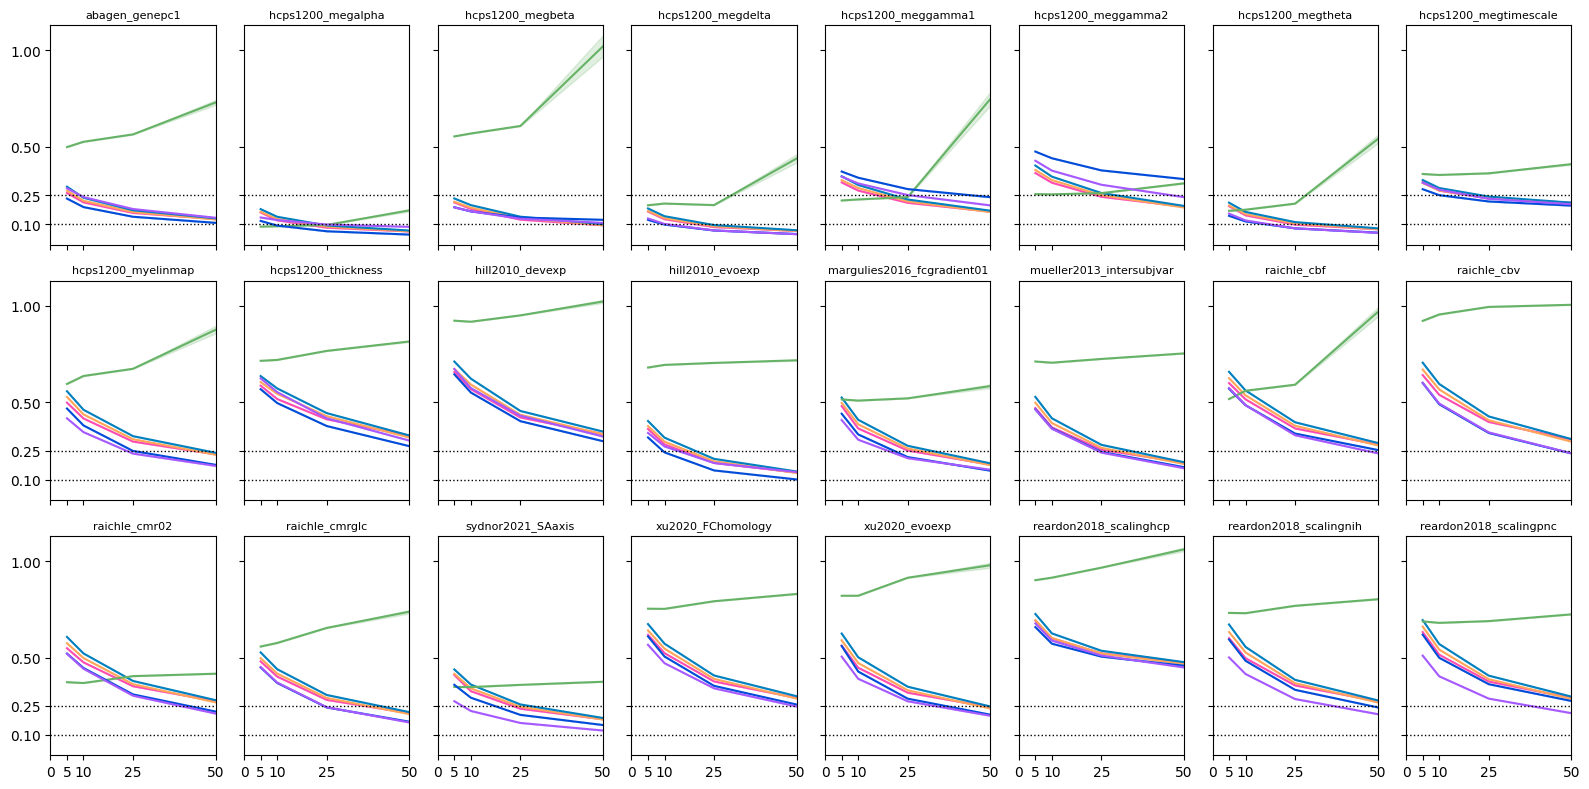

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(3,8, figsize = (16,8), sharex=True, sharey=True)


for mi, maptag in enumerate(maptags):
    row = mi // 8; col = mi % 8
    
    everything_rmse = {}
    
    for pi, percentage in enumerate(test_percentages):
        tags, results = joblib.load( projdir + \
                                   f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
        perf_scores = pd.concat( [ results[4][i][0].loc['rmse'] for i in range(100) ] )
        everything_rmse[percentage] = perf_scores / np.std(src_pvdata[maptag])

    df = pd.DataFrame(everything_rmse).T
    sns.lineplot(df, palette = apal, legend=False, err_style = 'band', errorbar='ci', dashes= False, ax=axs[row,col])
    axs[row,col].set_title(maptag, fontsize = 8)
    axs[row,col].axhline(y=0.1, linewidth=1, linestyle='dotted', color='k')
    axs[row,col].axhline(y=0.25, linewidth=1, linestyle ='dotted', color = 'k')

    
    axs[row,col].set_xlim([0,50])
    axs[row,col].set_yticks([0.1, 0.25, 0.5, 1.0])
    axs[row,col].set_xticks([0, 5, 10, 25, 50]) 
plt.tight_layout()

In [117]:
info = joblib.load( projdir + '/results/stats/neuromaps_fullmap_globalstats.pkl' )
extended_cpal = {}

for maptag in maptags:
    extended_cpal[maptag] = cpal[info.loc[maptag]['category']]

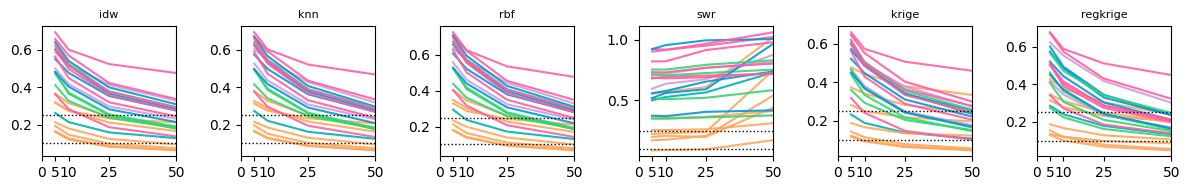

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1,6, figsize = (12,2), sharex=True)

examples_list = ['abagen_genepc1', 'hcps1200_megtimescale', 'hcps1200_thickness', 'margulies2016_fcgradient01', \
                 'raichle_cbf', 'reardon2018_scalinghcp']
category_list = ['gene expression', 'MEG', 'structural', 'functional', 'metabolism', 'expansion']

for ai, approach in enumerate(approaches):
    
    every_density_rmse = {}
    
    for pi, percentage in enumerate(test_percentages):

        everything_rmse = {}
        for maptag in maptags:
            tags, results = joblib.load( projdir + \
            f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
            perf_scores = np.array( [ results[4][i][0].loc['rmse'][approach] for i in range(100) ] )

            everything_rmse[maptag] = perf_scores / np.std(src_pvdata[maptag])
        
        everything_rmse = pd.DataFrame(everything_rmse)
        every_density_rmse[percentage] = everything_rmse.T
    
    # build long dataframe
    df = (
    pd.concat(every_density_rmse, names=["percentage"])  # adds the dict key as a level
    .stack()                    
    .rename("value")# name the values column
    .reset_index()
    )
    
    # optional: rename columns nicely
    df.columns = ["percentage", "maptag", "replicate", "value"]

    cat = []
    
    for row in range(len(df)):
        cat.append( info.loc[ df.at[row, 'maptag'] ]['category'] )
    df['category'] = cat
    sns.lineplot(df, x='percentage', y='value', hue = 'maptag', alpha=0.9, \
                 palette = extended_cpal, errorbar=None, legend=False, dashes= False, ax=axs[ai])
    axs[ai].set_title(approach, fontsize = 8)
    axs[ai].axhline(y=0.1, linewidth=1, linestyle='dotted', color = 'k')
    axs[ai].axhline(y=0.25, linewidth=1, linestyle='dotted', color = 'k')
    axs[ai].set_xlim([0,50])
    axs[ai].set_ylabel('')
    axs[ai].set_xlabel('')
    #axs[ai].set_yticks([0.1, 0.25, 0.5, 1.0])
    axs[ai].set_xticks([0, 5, 10, 25, 50]) 

plt.tight_layout()

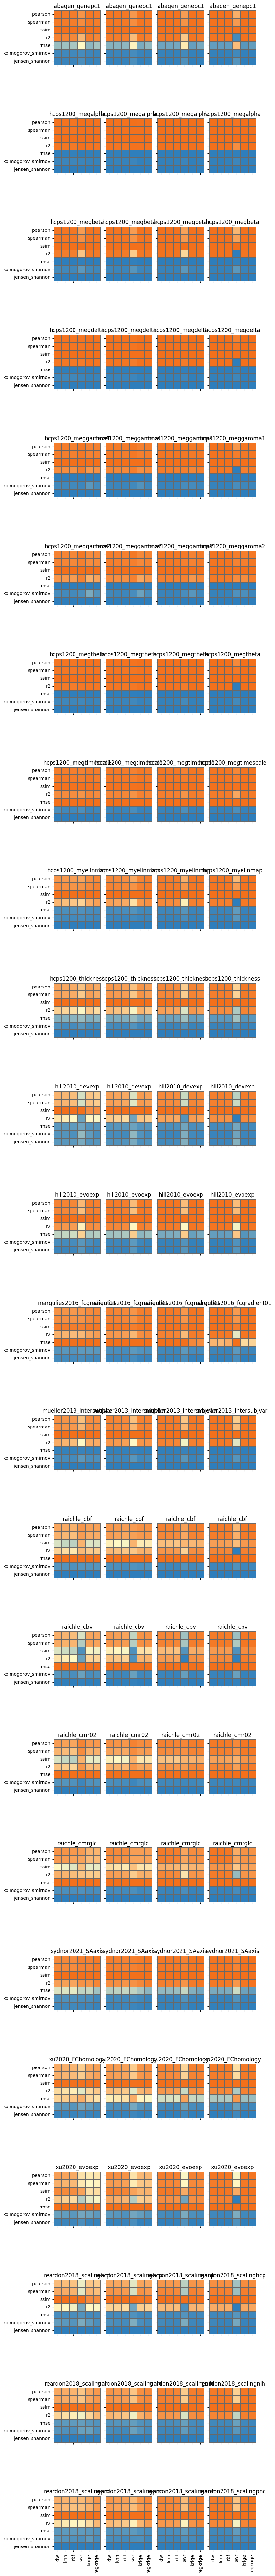

In [120]:
concat_rank_scores = pd.DataFrame()
strategy = 'dsk33'
geometry = 'reduced-midthickness'

#for mi, maptag in enumerate(maptags):

fig, axs = plt.subplots(len(maptags),4, figsize = (8, 80), sharex=True, sharey=True)

for mi, maptag in enumerate(maptags):
    
    for pi, percentage in enumerate(test_percentages):
        
        tags, results = joblib.load( projdir + \
                               f'/results/{datasource}/{strategy}/{space}_{maptag}_{geometry}_{datasource}_samp-{strategy}_pct-{str(percentage)}.pkl')
        
        perf_scores = None
        
        for i in range(niters):
            #rank_scores = results[4][i][1]

            
            
            if i ==0:
                perf_scores = results[4][i][0].loc[metrics_to_consider[:-1]].fillna(0)
            else:
                perf_scores += results[4][i][0].loc[metrics_to_consider[:-1]].fillna(0)
        perf_scores= perf_scores / 100
    
        sns.heatmap( perf_scores, square=True, cmap = gnrd, vmin=0, \
                     vmax=1, linewidth = 1, linecolor = 'dimgray', ax=axs[mi, pi], cbar=False)
            #concat_rank_scores[maptag + "-" + str(percentage) + "-" + str(i) ] = rank_scores
        #plt.savefig(projdir + "/figs/main/grf_random_samples_mean_rank_scores_heatmap.svg")
        axs[mi, pi].set_title(maptag)
plt.tight_layout()

In [157]:
concat_rank_scores_rotate = concat_rank_scores.T

In [159]:
concat_rank_scores_rotate['mae-sillnorm'] = variogram_gof_plotdata['mae']
concat_rank_scores_rotate['percentage'] = variogram_gof_plotdata['percentage']
concat_rank_scores_rotate['sample_i'] = sample_global_i_s.flatten()

In [162]:
concat_rank_scores_rotate[['maptag', 'percentage', 'iteration']] = (
    concat_rank_scores_rotate.index
      .to_series()
      .str.split('-', expand=True)
)


In [165]:
concat_rank_scores_rotate.index = np.arange(len(concat_rank_scores_rotate))

#joblib.dump(concat_rank_scores_rotate, projdir + '/results/stats/neuromaps_collected_per_sample_sill-normalized.pkl')

In [170]:
df_wide = concat_rank_scores_rotate.groupby("maptag").mean(approaches)
rorder = df_wide.mean().sort_values(ascending=False).index
rorder

Index(['krige', 'regkrige', 'idw', 'knn', 'rbf', 'swr', 'sample_i',
       'mae-sillnorm'],
      dtype='object')

In [171]:
df_wide = df_wide[rorder[1:-2]]

In [172]:
df_wide = df_wide.reindex(global_i_s.index)

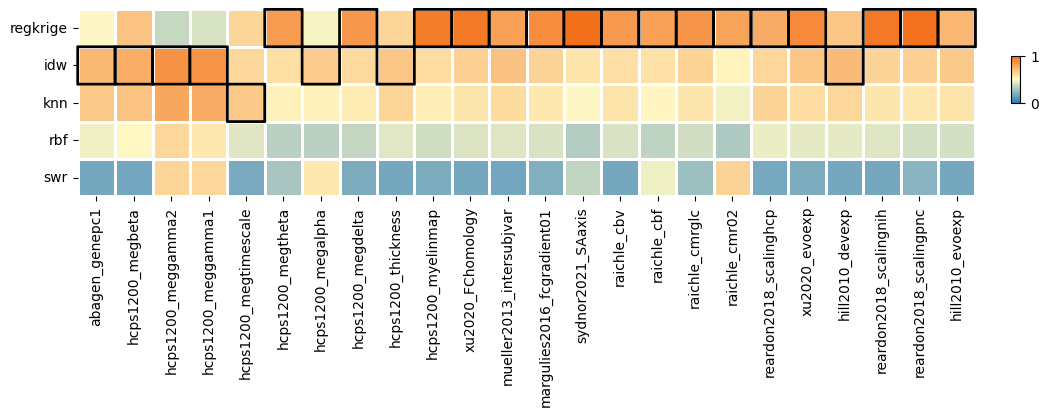

In [175]:
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize = (12,4))

data = df_wide.T

sns.heatmap( data, square = True, vmin = 0, vmax = 1, \
             linewidth = 2, linecolor = 'w',cmap = gnrd, \
             cbar = False, ax=ax)


for maptag in data.columns:
    col_label = maptag
    row_label = data[maptag].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))
    
axins = inset_axes(
    ax,
    width="2%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()
plt.show()

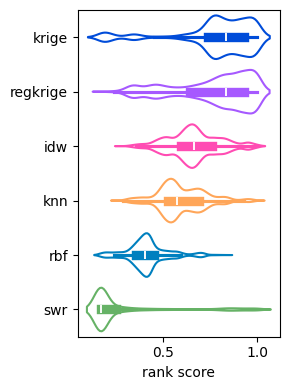

In [178]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (3,4), sharex=True)

sns.violinplot(concat_rank_scores_rotate[approaches], order = rorder[:6], orient = 'h', inner = 'box', palette=apal,\
               fill=False, ax=ax)
ax.set_xlabel("rank score")
#sns.boxplot(concat_everything.T, order = methods_order, orient = 'h', fill=False, color = 'k', ax=axs[1], fliersize = 3)
#axs[1].set_xlabel("rank score")
# Increase median line width

plt.tight_layout()

In [ ]:
df_long = concat_rank_scores_rotate.melt(
    id_vars=["maptag", "mae-sillnorm", "percentage", "sample_i"],
    value_vars=approaches,
    var_name="approach",
    value_name="rank"
)

df_long['map_i'] = np.zeros(len(df_long))

for row in range(len(df_long)):

    maptag = df_long.at[row, 'maptag']
    df_long.at[row, 'map_i'] = global_i_s.loc[maptag, 'i']

df_long['category'] = np.zeros(len(df_long))
for i in range(len(df_long)):
    df_long.at[i, 'category'] = global_i_s.loc[ df_long['maptag'][i] ]['category']

#joblib.dump(df_long, projdir + '/results/stats/neuromaps_collected_ols_in_sill-normalized.pkl')